# Contact Force Regression — ResNet18 Training

Trains a ResNet18-based regression model to predict **contact force magnitude and angle** from grayscale particle contact-region images.

**Training strategy (two phases):**
| Phase | Backbone | Learning rate | Epochs |
|---|---|---|---|
| 1 — Warmup | Frozen | 1 × 10⁻⁴ | up to 1000 (early stopping) |
| 2 — Fine-tuning | Unfrozen | 1 × 10⁻⁵ | up to 1000 (early stopping) |

**Input:** 224 × 224 greyscale images (converted to 3-channel for ImageNet normalisation)  
**Output:** `[force_magnitude, force_angle]` (MSE loss on each component independently)

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import math
import matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm.notebook import tqdm  # specific for Jupyter

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



Using device: cuda


## Custom dataset and callbacks

`Dataset` loads images from a directory (sorted numerically) and pairs them with labels from a `.npy` file of shape `(N, 2)` — `[force_magnitude, force_angle]` per row.

`EarlyStopping` monitors validation loss, saves the best checkpoint, and halts training if no improvement exceeds `min_delta` for `patience` consecutive epochs.

In [ ]:
class Dataset(Dataset):
    def __init__(self, npy_file, img_dir, transform=None):
        """
        Args:
            npy_file (string): Path to the .npy file containing labels [N, 2].
            img_dir (string): Directory with all the images.
            transform (callable, optional): Transform to be applied on a sample.
        """
        # 1. Load Labels
        # Assumes shape is (N, 2) -> [[force1, angle1], [force2, angle2], ...]
        self.labels = np.load(npy_file).astype(np.float32)
        
        # 2. List Images
        # We use sorted() to ensure the order matches the rows in the npy file
        # Make sure your filenames sort correctly (e.g., img_0.png, img_1.png...)
        self.img_dir = Path(img_dir)
        self.img_paths = sorted(list(self.img_dir.glob("*.png")))
        
        # 3. Sanity Check
        if len(self.labels) != len(self.img_paths):
            print(f"WARNING: Mismatch! Found {len(self.labels)} labels but {len(self.img_paths)} images.")
        
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Load Image
        img_path = self.img_paths[idx]
        
        # Convert to RGB for ResNet
        image = Image.open(img_path).convert('L')
        
        if self.transform:
            image = self.transform(image)
        
        # Load Label: [Force, Angle]
        # We convert to Tensor explicitly
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        return image, label
    
    
class EarlyStopping:
    def __init__(self, patience, min_delta, path):
        """
        Args:
            patience (int): How many epochs to wait after last time validation loss improved.
            min_delta (float): Minimum change in the monitored quantity to qualify as an improvement.
            path (str): Path for the checkpoint to be saved to.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        # 1. First Epoch
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
        
        # 2. Loss got worse or didn't improve enough
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        
        # 3. Loss improved -> Save Model & Reset Counter
        else:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decreases.'''
        torch.save(model.state_dict(), self.path)
        print(f'Validation loss decreased. Saving model to {self.path} ...')

## Load and split data

Reads the label file (`labels.npy`, shape `(N, 2)`) and the matching image directory, applies ImageNet normalisation after converting each greyscale image to 3 channels, then splits the dataset 70 / 15 / 15 into train, validation, and test sets.

Total: 31500 | Train: 22050 | Val: 4725 | Test: 4725
Batch Image Shape: torch.Size([64, 3, 224, 224])
Batch Label Shape: torch.Size([64, 2])


Text(0.5, 1.0, 'tensor([ 0.3341, -0.5932])')

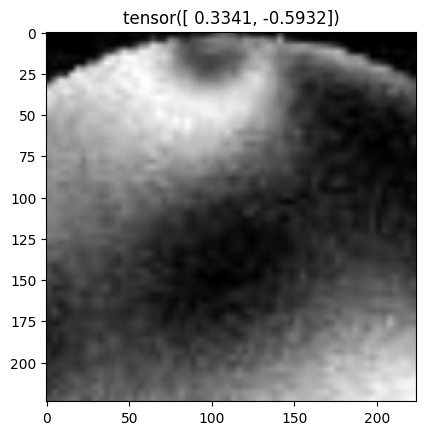

In [8]:
# --- Configuration ---
# Adjust these to match your actual data stats
BATCH_SIZE    = 64
LABEL_PATH      = r'C:\Users\jcTSAI\Desktop\PE_Force_ML_Data\synth_img_poly_stress_contact_crop_202601/labels.npy'
IMG_DIR       = r'C:\Users\jcTSAI\Desktop\PE_Force_ML_Data\synth_img_poly_stress_contact_crop_202601/'
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# --- Instantiate Dataset ---
dataset = Dataset(
    npy_file=LABEL_PATH, 
    img_dir=IMG_DIR, 
    transform=data_transform
)

# 2. Calculate Split Sizes (70% / 15% / 15%)
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size   = int(0.15 * total_size)
test_size  = total_size - train_size - val_size # Use subtraction to ensure sum matches exactly

print(f"Total: {total_size} | Train: {train_size} | Val: {val_size} | Test: {test_size}")

# 3. Perform the 3-Way Split
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# 4. Create DataLoaders
# Train: Shuffle=True (Critical)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader  = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- Sanity Check ---
# Get one batch to verify shapes
images, labels = next(iter(train_loader))

print(f"Batch Image Shape: {images.shape}")  # Should be [BATCH_SIZE, 3, 224, 224]
print(f"Batch Label Shape: {labels.shape}")  # Should be [BATCH_SIZE, 2]

# Show first 5 labels from this batch
plt.imshow(images[10][0], cmap='gray')
plt.title(labels[10])

## Model architecture

Loads a pretrained ResNet18 and replaces its classification head with a regression head:

```
Linear(512 → 256) → ReLU → Dropout(0.2) → Linear(256 → 2)
```

All backbone parameters are frozen for the warmup phase; only the new head is trained.

In [ ]:
def get_model(device, output_dim=2):   
    # 1. Load Pre-trained Model
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    # 2. Freeze the 'Body' (Feature Extractor)
    for param in model.parameters():
        param.requires_grad = False
        
    # 3. Replace the 'Head' (Classifier -> Regressor)
    num_ftrs = model.fc.in_features  # 512
    
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 256),
        nn.ReLU(),
        nn.Dropout(0.2),            # Drop 20% of neurons to prevent overfitting
        nn.Linear(256, output_dim)  # Output: [Force, Angle]
    )
    
    # Move to GPU/CPU
    model = model.to(device)
    return model

# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model(device)


########## DEFINE LOSS AND OPTIMIZER #########################
optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)

print("Model Structure (Final Layer):")
print(model.fc)

Loading ResNet18 with ImageNet weights...
Model Structure (Final Layer):
Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=256, out_features=2, bias=True)
)


## Phase 1 — Warmup training (frozen backbone)

Trains only the regression head with Adam (lr = 1 × 10⁻⁴).  
Loss = MSE(force) + MSE(angle), monitored separately per component.  
Best checkpoint is saved; training halts early if validation loss does not improve for `PATIENCE` epochs.

In [6]:
# --- Configuration ---
EPOCHS = 1000
PATIENCE = 20  # Stop if no improvement for 5 epochs
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = 'contact_force_regression_test_0130.pth'
min_delta = 0.001

# Initialize Callback
stopper = EarlyStopping(min_delta= min_delta, patience=PATIENCE, path= MODEL_PATH)

# Lists for plotting
history = []

print(f"Starting training on {DEVICE}...")
for epoch in range(EPOCHS):
    
    # ==========================
    # Training
    # ==========================
    model.train()
    train_loss = 0.0
    train_loss_force = 0.0
    train_loss_angle = 0.0
    
    # Progress bar for this epoch
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    
    for inputs, labels in loop:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        # Calculate Loss
        loss_f = F.mse_loss(outputs[:, 0], labels[:, 0])
        loss_a = F.mse_loss(outputs[:, 1], labels[:, 1])
        loss = loss_f + loss_a
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_loss_force += loss_f.item()
        train_loss_angle += loss_a.item()
        
        # Update progress bar
        loop.set_postfix(loss=loss.item())
        
    avg_train_loss = train_loss / len(train_loader)
    avg_train_f    = train_loss_force / len(train_loader)
    avg_train_a    = train_loss_angle / len(train_loader)
    
    # ==========================
    # Validation
    # ==========================
    model.eval()
    val_loss_total = 0.0
    val_loss_force = 0.0
    val_loss_angle = 0.0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            
            l_f = F.mse_loss(outputs[:, 0], labels[:, 0])
            l_a = F.mse_loss(outputs[:, 1], labels[:, 1])
            l_total = l_f + l_a
            
            # Sum up batch errors
            val_loss_total += l_total.item()
            val_loss_force += l_f.item()
            val_loss_angle += l_a.item()
            
    # Calculate Averages
    avg_val_loss = val_loss_total / len(val_loader)
    avg_val_f    = val_loss_force / len(val_loader)
    avg_val_a    = val_loss_angle / len(val_loader)
    
    # ==========================
    # Log & Print
    # ==========================
    print(f"Epoch {epoch+1}: "
          f"Train Loss: {avg_train_loss:.4f} [Force: {avg_train_f:.4f}, Angle: {avg_train_a:.4f}] | "
          f"Val Loss: {avg_val_loss:.4f} [Force: {avg_val_f:.4f}, Angle: {avg_val_a:.4f}]")
    
    # Append to history
    history.append({
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'train_force': avg_train_f,
        'train_angle': avg_train_a,
        'val_loss': avg_val_loss,
        'val_force': avg_val_f,
        'val_angle': avg_val_a
    })
    
    # ==========================
    # Check Early Stopping
    # ==========================
    stopper(avg_val_loss, model)
    if stopper.early_stop:
        print("Early stopping triggered!")
        break

Starting training on cuda...


Epoch 1/1000:   0%|          | 0/345 [00:00<?, ?it/s]

Epoch 1: Train Loss: 0.1511 [Force: 0.0722, Angle: 0.0789] | Val Loss: 0.0970 [Force: 0.0341, Angle: 0.0629]
Validation loss decreased. Saving model to contact_force_regression_test_0130.pth ...


Epoch 2/1000:   0%|          | 0/345 [00:00<?, ?it/s]

Epoch 2: Train Loss: 0.1024 [Force: 0.0364, Angle: 0.0660] | Val Loss: 0.0850 [Force: 0.0250, Angle: 0.0599]
Validation loss decreased. Saving model to contact_force_regression_test_0130.pth ...


...

Epoch 55: Train Loss: 0.0412 [Force: 0.0109, Angle: 0.0303] | Val Loss: 0.0614 [Force: 0.0114, Angle: 0.0501]
EarlyStopping counter: 18 out of 20


Epoch 56/1000:   0%|          | 0/345 [00:00<?, ?it/s]

Epoch 56: Train Loss: 0.0399 [Force: 0.0105, Angle: 0.0294] | Val Loss: 0.0617 [Force: 0.0114, Angle: 0.0503]
EarlyStopping counter: 19 out of 20


Epoch 57/1000:   0%|          | 0/345 [00:00<?, ?it/s]

Epoch 57: Train Loss: 0.0399 [Force: 0.0107, Angle: 0.0292] | Val Loss: 0.0631 [Force: 0.0130, Angle: 0.0501]
EarlyStopping counter: 20 out of 20
Early stopping triggered!


## Phase 2 — Fine-tuning (full network)

Reloads the best warmup checkpoint, unfreezes all layers, and creates a new Adam optimiser with a much lower learning rate (1 × 10⁻⁵) to adapt the pretrained backbone without overwriting learned features.

In [ ]:
model.load_state_dict(torch.load(MODEL_PATH))
print("Loaded best weights from Phase 1.")

# 2. Unfreeze All Layers
for param in model.parameters():
    param.requires_grad = True

# 3. Create a New Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)


Loaded best weights from Phase 1.


### Fine-tuning loop

In [ ]:
# Number of epochs for fine-tuning 
FINE_TUNE_EPOCHS = 1000
FINE_TUNE_PATIENCE = 20
FINE_TUNE_MIN_DELTA = 0.0001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FINE_TUNE_MODEL_PATH = 'contact_force_regression_test_0130.pth'
stopper = EarlyStopping(patience=20, min_delta=0.0001, path=FINE_TUNE_MODEL_PATH)


print(f"Starting Fine-Tuning (LR=1e-5) on {DEVICE}...")

# Reuse the same lists or create new ones if you want separate plots
ft_history = [] 

for epoch in range(FINE_TUNE_EPOCHS):
    
    # --- Training ---
    model.train()
    train_loss = 0.0
    train_loss_force = 0.0
    train_loss_angle = 0.0
    
    loop = tqdm(train_loader, desc=f"Fine-Tune Epoch {epoch+1}/{FINE_TUNE_EPOCHS}", leave=False)
    
    for inputs, labels in loop:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss_f = F.mse_loss(outputs[:, 0], labels[:, 0])
        loss_a = F.mse_loss(outputs[:, 1], labels[:, 1])
        loss = loss_f + loss_a
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_loss_force += loss_f.item()
        train_loss_angle += loss_a.item()
        loop.set_postfix(loss=loss.item())
        
    avg_train_loss = train_loss / len(train_loader)
    avg_train_f    = train_loss_force / len(train_loader)
    avg_train_a    = train_loss_angle / len(train_loader)
    
    # --- Validation ---
    model.eval()
    val_loss_total = 0.0
    val_loss_force = 0.0
    val_loss_angle = 0.0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            
            l_f = F.mse_loss(outputs[:, 0], labels[:, 0])
            l_a = F.mse_loss(outputs[:, 1], labels[:, 1])
            val_loss_total += (l_f + l_a).item()
            val_loss_force += l_f.item()
            val_loss_angle += l_a.item()

    avg_val_loss = val_loss_total / len(val_loader)
    avg_val_f    = val_loss_force / len(val_loader)
    avg_val_a    = val_loss_angle / len(val_loader)

    print(f"FT Epoch {epoch+1}: Train Loss: {avg_train_loss:.5f} [Force: {avg_train_f:.5f}, Angle: {avg_train_a:.5f}] | Val Loss: {avg_val_loss:.5f} [Force: {avg_val_f:.5f}, Angle: {avg_val_a:.5f}]")

    ft_history.append({'epoch': epoch+1,
                      'train_loss': avg_train_loss,
                      'train_force': avg_train_f,
                      'train_angle': avg_train_a,
                      'val_loss': avg_val_loss,
                      'val_force': avg_val_f,
                      'val_angle': avg_val_a})

    # --- Check Early Stopping ---
    stopper(avg_val_loss, model)
    if stopper.early_stop:
        print("Fine-tuning stopped early.")
        break


Starting Fine-Tuning (LR=1e-5) on cuda...


Fine-Tune Epoch 1/1000:   0%|          | 0/345 [00:00<?, ?it/s]

FT Epoch 1: Train Loss: 0.04073 [Force: 0.01036, Angle: 0.03037] | Val Loss: 0.04291 [Force: 0.00831, Angle: 0.03460]
Validation loss decreased. Saving model to contact_force_regression_test_0130_finetuned.pth ...


Fine-Tune Epoch 2/1000:   0%|          | 0/345 [00:00<?, ?it/s]

FT Epoch 2: Train Loss: 0.02958 [Force: 0.00803, Angle: 0.02155] | Val Loss: 0.03670 [Force: 0.00688, Angle: 0.02982]
Validation loss decreased. Saving model to contact_force_regression_test_0130_finetuned.pth ...


...

FT Epoch 219: Train Loss: 0.00210 [Force: 0.00109, Angle: 0.00100] | Val Loss: 0.00914 [Force: 0.00088, Angle: 0.00826]
EarlyStopping counter: 18 out of 20


Fine-Tune Epoch 220/1000:   0%|          | 0/345 [00:00<?, ?it/s]

FT Epoch 220: Train Loss: 0.00213 [Force: 0.00110, Angle: 0.00103] | Val Loss: 0.00910 [Force: 0.00082, Angle: 0.00828]
EarlyStopping counter: 19 out of 20


Fine-Tune Epoch 221/1000:   0%|          | 0/345 [00:00<?, ?it/s]

FT Epoch 221: Train Loss: 0.00215 [Force: 0.00112, Angle: 0.00103] | Val Loss: 0.00897 [Force: 0.00080, Angle: 0.00817]
EarlyStopping counter: 20 out of 20
Fine-tuning stopped early.


## Training history — loss curves

Plots train and validation MSE loss on a log scale for both phases concatenated on the epoch axis. Dashed ideal line shows convergence reference.

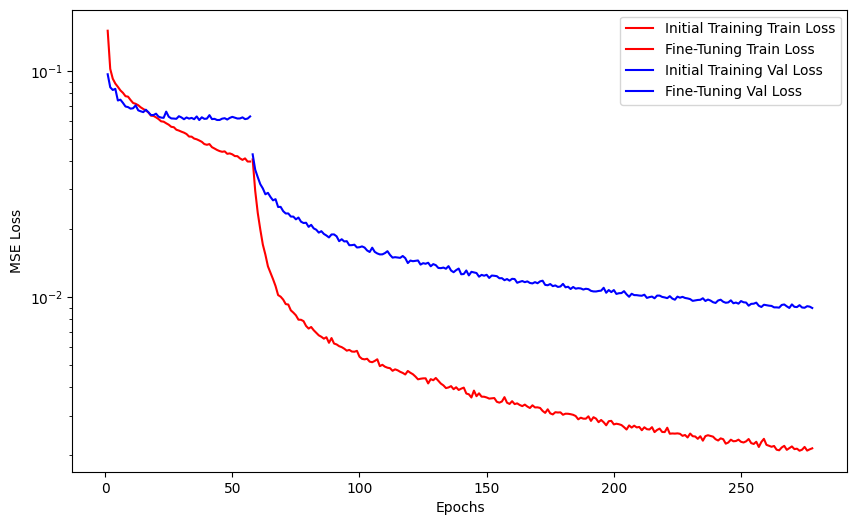

In [ ]:
epochs = [h['epoch'] for h in history]
val_losses = [h['val_loss'] for h in history]
train_losses = [h['train_loss'] for h in history]
ft_epochs = [h['epoch'] for h in ft_history]
ft_train_losses = [h['train_loss'] for h in ft_history]
ft_val_losses = [h['val_loss'] for h in ft_history]
plt.figure(figsize=(10,6))
plt.plot(epochs, train_losses,'r', label='Initial Training Train Loss')
plt.plot([e + epochs[-1] for e in ft_epochs], ft_train_losses, 'r', label='Fine-Tuning Train Loss')
plt.plot(epochs, val_losses,'b', label='Initial Training Val Loss')
plt.plot([e + epochs[-1] for e in ft_epochs], ft_val_losses, 'b', label='Fine-Tuning Val Loss')

plt.xlabel('Epochs')
plt.ylabel('MSE Loss')  
plt.legend()
plt.yscale('log')

## Evaluation on the test set

Loads the fine-tuned model weights, runs inference on the held-out test set, and plots predicted vs. true values for force magnitude (log scale) and force angle.

In [19]:
test_model_path = 'contact_force_regression_test_0130_finetuned.pth'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model(DEVICE)
model.load_state_dict(torch.load(test_model_path))
model.eval()
test_preds = []
test_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        test_preds.append(outputs.cpu().numpy())
        test_labels.append(labels.cpu().numpy())
test_preds = np.concatenate(test_preds, axis=0)
test_labels = np.concatenate(test_labels, axis=0)


Loading ResNet18 with ImageNet weights...


Text(0.5, 1.0, 'Angle: True vs Predicted')

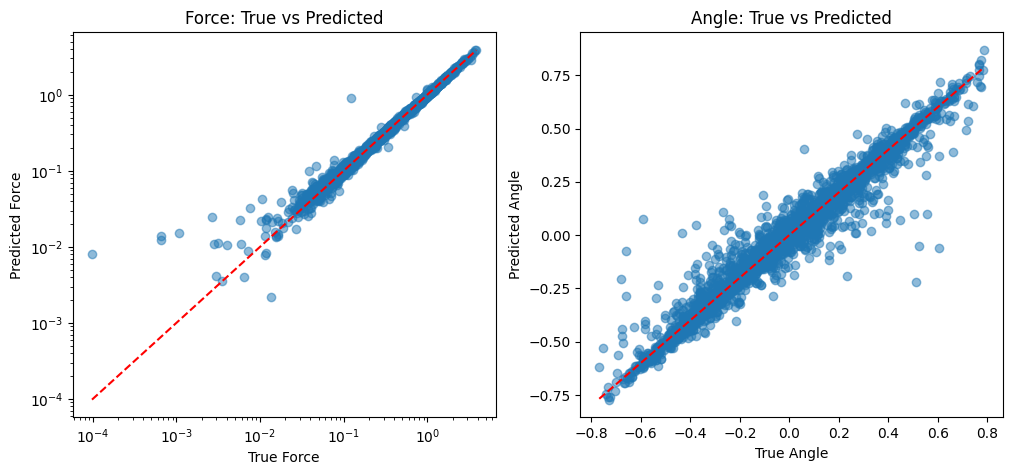

In [17]:
#plot predicted vs true for force and angle
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.scatter(test_labels[:, 0], test_preds[:, 0], alpha=0.5)
plt.plot([test_labels[:, 0].min(), test_labels[:, 0].max()], [test_labels[:, 0].min(), test_labels[:, 0].max()], 'r--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('True Force')    
plt.ylabel('Predicted Force')
plt.title('Force: True vs Predicted')

plt.subplot(1, 2, 2)
plt.scatter(test_labels[:, 1], test_preds[:, 1], alpha=0.5)
plt.plot([test_labels[:, 1].min(), test_labels[:, 1].max()], [test_labels[:, 1].min(), test_labels[:, 1].max()], 'r--')
plt.xlabel('True Angle')    
plt.ylabel('Predicted Angle')
plt.title('Angle: True vs Predicted')